In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path


In [4]:
stress_dir = Path(r"D:\Git_repository\result folder\data\analysis_results\stress\0")
med_dir    = Path(r"D:\Git_repository\result folder\data\analysis_results\conventional meditation\0")  # or ...\vr\0

print("Stress dir exists? ", stress_dir.exists(), "|", stress_dir)
print("Medit  dir exists? ", med_dir.exists(),    "|", med_dir)
print("Stress CSV exists? ", (stress_dir/"downsample_1s.csv").exists())
print("Medit  CSV exists? ", (med_dir/"downsample_1s.csv").exists())
print("Stress HRV exists? ", (stress_dir/"hrv_summary.csv").exists())
print("Medit  HRV exists? ", (med_dir/"hrv_summary.csv").exists())

Stress dir exists?  True | D:\Git_repository\result folder\data\analysis_results\stress\0
Medit  dir exists?  True | D:\Git_repository\result folder\data\analysis_results\conventional meditation\0
Stress CSV exists?  True
Medit  CSV exists?  True
Stress HRV exists?  True
Medit  HRV exists?  True


In [5]:

def load_pair(path):
    ts = pd.read_csv(path/"downsample_1s.csv")
    hrv = pd.read_csv(path/"hrv_summary.csv") if (path/"hrv_summary.csv").exists() else pd.DataFrame()
    return ts, hrv

stress_ts, stress_hrv = load_pair(stress_dir)
med_ts,    med_hrv    = load_pair(med_dir)

def load_pair(path):
    ts = pd.read_csv(path/"downsample_1s.csv")
    hrv = pd.read_csv(path/"hrv_summary.csv") if (path/"hrv_summary.csv").exists() else pd.DataFrame()
    return ts, hrv

stress_ts, stress_hrv = load_pair(stress_dir)
med_ts,    med_hrv    = load_pair(med_dir)


SCL_mean_stress              4.018
SCL_mean_medit               5.304
ΔSCL_medit_minus_stress      1.286
HR_mean_stress              88.685
HR_mean_medit               72.668
ΔHR_medit_minus_stress     -16.017
PVA_mean_stress             19.810
PVA_mean_medit              15.724
ΔPVA_medit_minus_stress     -4.086
RMSSD_ms_stress            265.631
RMSSD_ms_medit             225.851
ΔRMSSD_ms                  -39.780
dtype: float64


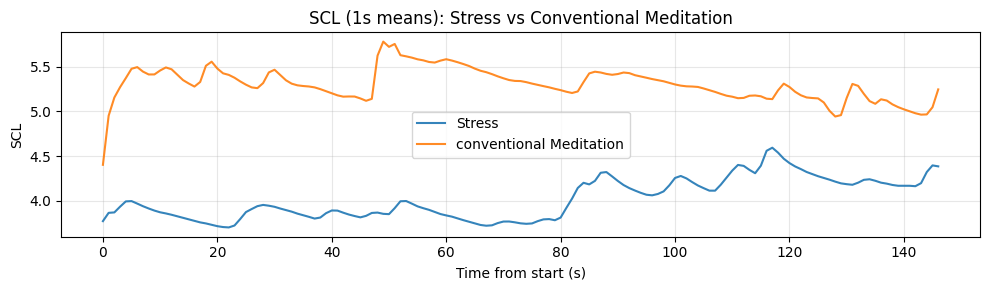

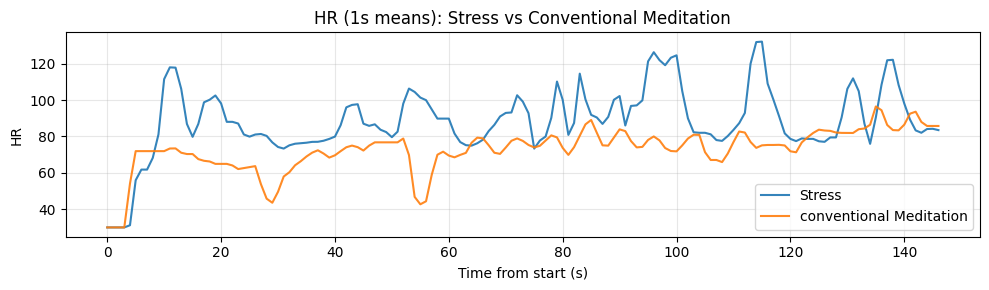

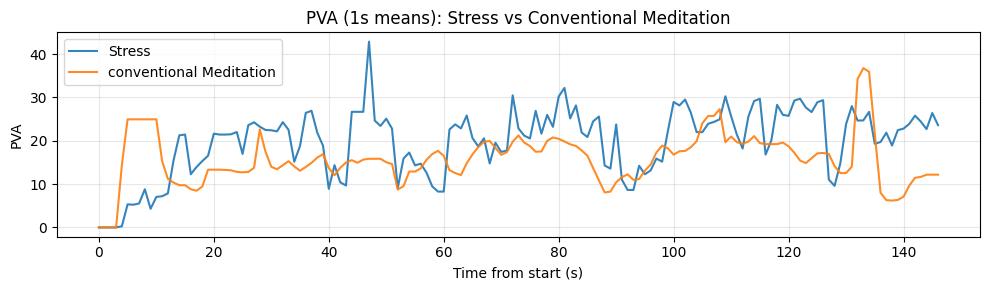

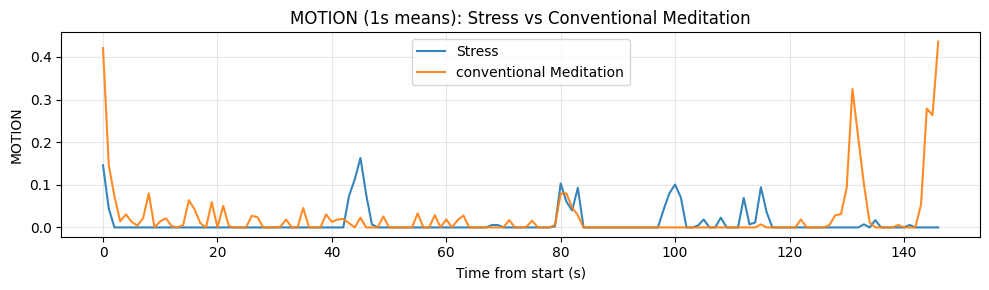

In [6]:

# Align time to the overlap window for clean overlay plots
tmin = max(stress_ts["sec"].min(), med_ts["sec"].min())
tmax = min(stress_ts["sec"].max(), med_ts["sec"].max())
S = stress_ts[(stress_ts["sec"]>=tmin)&(stress_ts["sec"]<=tmax)].reset_index(drop=True)
M = med_ts[(med_ts["sec"]>=tmin)&(med_ts["sec"]<=tmax)].reset_index(drop=True)

def mean_nan(df, col): 
    return float(np.nanmean(df[col])) if col in df.columns else np.nan

summary = {
    "SCL_mean_stress": mean_nan(S,"SCL"),
    "SCL_mean_medit" : mean_nan(M,"SCL"),
    "ΔSCL_medit_minus_stress": mean_nan(M,"SCL") - mean_nan(S,"SCL"),
    "HR_mean_stress" : mean_nan(S,"HR"),
    "HR_mean_medit"  : mean_nan(M,"HR"),
    "ΔHR_medit_minus_stress" : mean_nan(M,"HR") - mean_nan(S,"HR"),
    "PVA_mean_stress": mean_nan(S,"PVA"),
    "PVA_mean_medit" : mean_nan(M,"PVA"),
    "ΔPVA_medit_minus_stress": mean_nan(M,"PVA") - mean_nan(S,"PVA"),
}

if not stress_hrv.empty and not med_hrv.empty:
    # convert s→ms for readability
    rmssd_stress_ms = float(stress_hrv.loc[0,"RMSSD_s"])*1000 if "RMSSD_s" in stress_hrv.columns else np.nan
    rmssd_medit_ms  = float(med_hrv.loc[0,"RMSSD_s"])*1000  if "RMSSD_s" in med_hrv.columns else np.nan
    summary |= {
        "RMSSD_ms_stress": rmssd_stress_ms,
        "RMSSD_ms_medit" : rmssd_medit_ms,
        "ΔRMSSD_ms"      : rmssd_medit_ms - rmssd_stress_ms
    }

print(pd.Series(summary).round(3))

# --- Overlay plots ---
def overlay(col, ylabel=None):
    if col not in S.columns or col not in M.columns: 
        return
    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(S["sec"]-tmin, S[col], label="Stress", alpha=.9)
    ax.plot(M["sec"]-tmin, M[col], label="conventional Meditation", alpha=.9)
    ax.set_title(f"{col} (1s means): Stress vs Conventional Meditation")
    ax.set_xlabel("Time from start (s)"); ax.set_ylabel(ylabel or col); ax.grid(alpha=.3); ax.legend()
    plt.tight_layout(); plt.show()

for c in ["SCL","HR","PVA","TEMP","MOTION"]:
    overlay(c)

In [7]:
method_label = med_dir.parent.name        # e.g. "conventional meditation" or "vr"
subject_code = med_dir.name               # e.g. "0"
out_root = med_dir.parent.parent / "_paired_outputs" / method_label / subject_code
out_root.mkdir(parents=True, exist_ok=True)
print("Saving to:", out_root)

Saving to: D:\Git_repository\result folder\data\analysis_results\_paired_outputs\conventional meditation\0


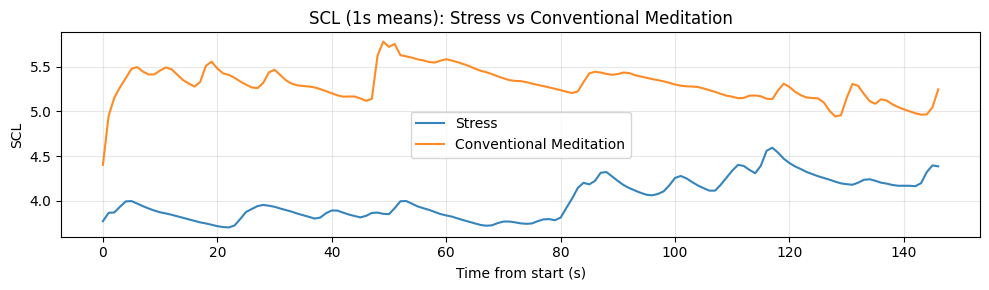

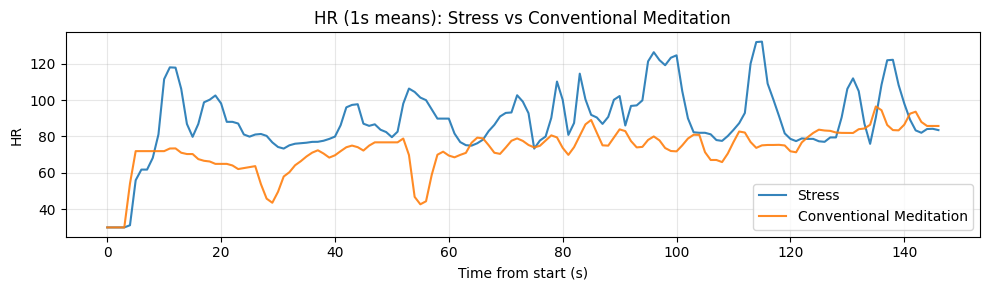

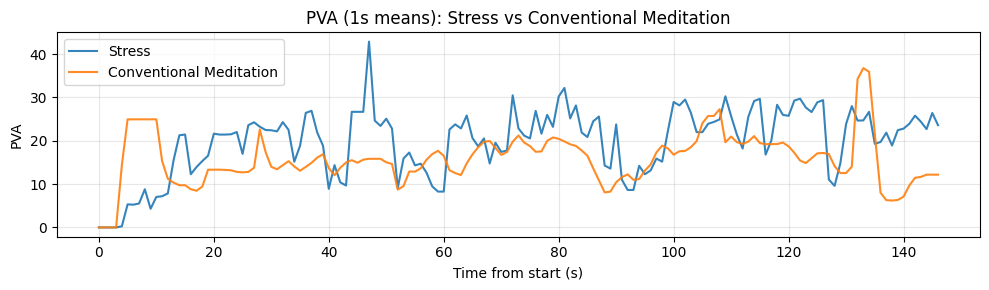

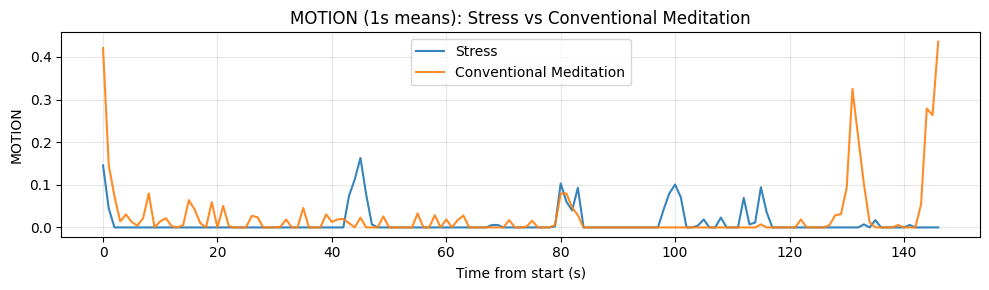

Done. Files written to: D:\Git_repository\result folder\data\analysis_results\_paired_outputs\conventional meditation\0


In [8]:
S.to_csv(out_root / "stress_1s.csv", index=False)
M.to_csv(out_root / "meditation_1s.csv", index=False)
pd.Series(summary, name="value").to_frame().to_csv(out_root / "summary_delta.csv")

# Save HRV tables if present in memory
try:
    if isinstance(stress_hrv, pd.DataFrame) and not stress_hrv.empty:
        stress_hrv.to_csv(out_root / "stress_hrv.csv", index=False)
    if isinstance(med_hrv, pd.DataFrame) and not med_hrv.empty:
        med_hrv.to_csv(out_root / "meditation_hrv.csv", index=False)
except NameError:
    # hrvs not loaded this run; ignore
    pass

# ---------- Save overlay plots ----------
def save_overlay(col, label_medit="Conventional Meditation", ylabel=None):
    if col not in S.columns or col not in M.columns:
        return
    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(S["sec"]-tmin, S[col], label="Stress", alpha=.9)
    ax.plot(M["sec"]-tmin, M[col], label=label_medit, alpha=.9)
    ax.set_title(f"{col} (1s means): Stress vs {label_medit}")
    ax.set_xlabel("Time from start (s)")
    ax.set_ylabel(ylabel or col)
    ax.grid(alpha=.3); ax.legend()
    fig.tight_layout()
    fig.savefig(out_root / f"overlay_{col}.png", dpi=150)
    plt.show()

label = "VR Meditation" if method_label.lower().startswith("vr") else "Conventional Meditation"
for c in ["SCL","HR","PVA","TEMP","MOTION"]:
    save_overlay(c, label_medit=label)

print("Done. Files written to:", out_root)